In [ ]:
!pip install -q transformers==4.46.3 datasets accelerate evaluate rouge-score bert-score sacrebleu sentencepiece peft bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 106.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 118.9 MB/s eta 0:00:00


In [ ]:
import os
import gc
import shutil
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sacrebleu
import evaluate

from tqdm import tqdm
from datasets import Dataset
from rouge_score import rouge_scorer
from bert_score import score as bertscore

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    DataCollatorForLanguageModeling,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training
)

In [ ]:
# ============================================================
# MOUNT DRIVE
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
BASE_DIR = "/content/drive/MyDrive/BLOOMZ_QLORA_Malayalam"

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(f"{BASE_DIR}/checkpoints", exist_ok=True)
os.makedirs(f"{BASE_DIR}/results", exist_ok=True)

print(BASE_DIR)

/content/drive/MyDrive/BLOOMZ_QLORA_Malayalam


In [ ]:
# ============================================================
# UPLOAD CSV FILES
# ============================================================

from google.colab import files
uploaded = files.upload()

Saving validation.csv to validation.csv
Saving train.csv to train.csv
Saving test.csv to test.csv


In [ ]:
# ============================================================
# LOAD CSV FILES
# ============================================================

train_df = pd.read_csv("/content/train.csv")
val_df = pd.read_csv("/content/validation.csv")
test_df = pd.read_csv("/content/test.csv")

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(7758, 3)
(970, 3)
(970, 3)


In [ ]:
# ============================================================
# CLEAN
# ============================================================

for df in [train_df, val_df, test_df]:
    df.dropna(subset=["article", "summary"], inplace=True)
    df["article"] = df["article"].astype(str)
    df["summary"] = df["summary"].astype(str)

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(7758, 3)
(970, 3)
(970, 3)


In [ ]:
def format_prompt(article, summary=None):

    prompt = f"""Summarize this Malayalam news article in Malayalam.

Article:
{article}

Summary:
"""

    if summary:
        prompt += summary

    return prompt

In [ ]:
# ============================================================
# FORMAT DATA
# ============================================================

train_df["text"] = train_df.apply(
    lambda x: format_prompt(x["article"], x["summary"]),
    axis=1
)

val_df["text"] = val_df.apply(
    lambda x: format_prompt(x["article"], x["summary"]),
    axis=1
)

In [ ]:
# ============================================================
# HF DATASETS
# ============================================================

train_dataset = Dataset.from_pandas(train_df[["text"]])
val_dataset = Dataset.from_pandas(val_df[["text"]])


In [ ]:
MODEL_NAME = "bigscience/bloomz-560m"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Model loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/222 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/715 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Model loaded


In [ ]:
model = prepare_model_for_kbit_training(model)

In [ ]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

trainable params: 786,432 || all params: 560,001,024 || trainable%: 0.1404


In [ ]:
# ============================================================
# TOKENIZATION
# ============================================================

MAX_LENGTH = 256

def tokenize_function(examples):

    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

In [ ]:
# ============================================================
# TOKENIZE
# ============================================================

train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

val_tokenized = val_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/7758 [00:00<?, ? examples/s]

Map:   0%|          | 0/970 [00:00<?, ? examples/s]

In [ ]:
# ============================================================
# DATA COLLATOR
# ============================================================

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

In [ ]:
gc.collect()
torch.cuda.empty_cache()
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
training_args = TrainingArguments(
    output_dir=f"{BASE_DIR}/checkpoints",

    learning_rate=2e-4,

    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,

    gradient_accumulation_steps=32,

    num_train_epochs=5,

    eval_strategy="epoch",
    save_strategy="epoch",

    fp16=False,

    logging_steps=50,

    save_total_limit=2,

    load_best_model_at_end=True,

    metric_for_best_model="eval_loss",
    greater_is_better=False,

    report_to="none",

    optim="paged_adamw_8bit"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=data_collator,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

In [ ]:
# ============================================================
# TRAIN
# ============================================================

trainer.train()

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
0,3.129100,3.077514
1,2.984000,2.974311
2,3.016500,3.133513
3,4.690100,4.345041


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

TrainOutput(global_step=969, training_loss=3.4009917331061743, metrics={'train_runtime': 7746.5351, 'train_samples_per_second': 5.007, 'train_steps_per_second': 0.156, 'total_flos': 1.4447302995345408e+16, 'train_loss': 3.4009917331061743, 'epoch': 3.996906419180201})

In [ ]:
MODEL_SAVE = f"{BASE_DIR}/final_bloomz_model"

trainer.save_model(MODEL_SAVE)
tokenizer.save_pretrained(MODEL_SAVE)

print("Saved")

Saved


In [ ]:
shutil.make_archive(
    f"{BASE_DIR}/final_bloomz_model",
    "zip",
    MODEL_SAVE
)

'/content/drive/MyDrive/BLOOMZ_QLORA_Malayalam/final_bloomz_model.zip'

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_SAVE)

In [ ]:
predictions = []
references = []
articles = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):

    article = row["article"]
    reference = row["summary"]

    prompt = format_prompt(article)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=256
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=64,
            num_beams=2,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    generated = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    pred = generated.split("Summary:")[-1].strip()

    predictions.append(pred)
    references.append(reference)
    articles.append(article)

100%|██████████| 970/970 [1:07:32<00:00,  4.18s/it]


In [ ]:
pred_df = pd.DataFrame({
    "Article": articles,
    "Reference": references,
    "Prediction": predictions
})

pred_df.to_csv(
    f"{BASE_DIR}/results/bloomz_predictions.csv",
    index=False
)

In [ ]:
rouge = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=False
)

r1 = []
r2 = []
rl = []

for ref, pred in zip(references, predictions):
    scores = rouge.score(ref, pred)

    r1.append(scores["rouge1"].fmeasure)
    r2.append(scores["rouge2"].fmeasure)
    rl.append(scores["rougeL"].fmeasure)

In [ ]:
bleu = sacrebleu.corpus_bleu(
    predictions,
    [references]
)

In [ ]:
P, R, F1 = bertscore(
    predictions,
    references,
    lang="ml"
)

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

In [ ]:
metrics_df = pd.DataFrame({
    "Metric": [
        "ROUGE-1",
        "ROUGE-2",
        "ROUGE-L",
        "BLEU",
        "BERTScore-F1"
    ],
    "Score": [
        np.mean(r1),
        np.mean(r2),
        np.mean(rl),
        bleu.score,
        F1.mean().item()
    ]
})

metrics_df.to_csv(
    f"{BASE_DIR}/results/bloomz_metrics.csv",
    index=False
)

metrics_df

,Metric,Score
0,ROUGE-1,0.038089
1,ROUGE-2,0.004227
2,ROUGE-L,0.038089
3,BLEU,7.623247
4,BERTScore-F1,0.693489


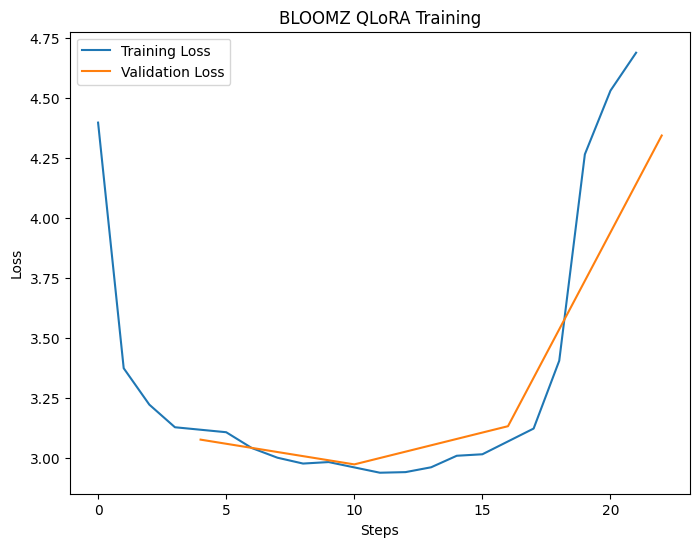

In [ ]:
logs = trainer.state.log_history
log_df = pd.DataFrame(logs)

plt.figure(figsize=(8,6))

if "loss" in log_df.columns:
    plt.plot(log_df["loss"].dropna(), label="Training Loss")

if "eval_loss" in log_df.columns:
    plt.plot(log_df["eval_loss"].dropna(), label="Validation Loss")

plt.legend()
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("BLOOMZ QLoRA Training")

plt.savefig(
    f"{BASE_DIR}/results/bloomz_training_curve.png"
)

plt.show()

In [ ]:
shutil.make_archive(
    f"{BASE_DIR}/bloomz_results",
    "zip",
    f"{BASE_DIR}/results"
)

'/content/drive/MyDrive/BLOOMZ_QLORA_Malayalam/bloomz_results.zip'

In [ ]:
from google.colab import files

files.download(f"{BASE_DIR}/final_bloomz_model.zip")
files.download(f"{BASE_DIR}/bloomz_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import random

indices = random.sample(range(len(predictions)), 10)

for idx in indices:

    print("=" * 120)
    print(f"SAMPLE {idx}")

    print("\nARTICLE:\n")
    print(articles[idx])

    print("\nREFERENCE SUMMARY:\n")
    print(references[idx])

    print("\nPREDICTED SUMMARY:\n")
    print(predictions[idx])

    print("\n")

SAMPLE 654

ARTICLE:

മാതൃരാജ്യമായ ഇംഗ്ലണ്ടിന്റെ നയങ്ങൾക്കും നിയമങ്ങൾക്കുമെതിരെ പ്രതികരിക്കാനായി ജോർജിയ ഒഴികെയുള്ള കോളനികളുടെ പ്രതിനിധികൾ 1774 ൽ ഫിലാഡൽഫിയയിൽ സമ്മേളിച്ചു. ഇത് ഒന്നാം കോണ്ടിനെന്റൽ കോൺഗ്രസ് എന്നറിയപ്പെടുന്നു. തുടർന്ന് വ്യവസായങ്ങൾക്കും വ്യാപാരത്തിനും ഏർപ്പെടുത്തിയിട്ടുള്ള നിയന്ത്രണങ്ങൾ നീക്കണമെന്നും തങ്ങളുടെ അംഗീകാരമില്ലാതെ നികുതി ചുമത്തരുതെന്നും ആവശ്യപ്പെട്ട് കോളനിജനത ഇംഗ്ലണ്ടിലെ രാജാവിന് നിവേദനം നൽകി. എന്നാൽ രാജാവ് ജനങ്ങളെ അടിച്ചമർത്താനായി സൈന്യത്തെ അയച്ചു. ഇത് ഇംഗ്ലണ്ടും കോളനികളും തമ്മിലുള്ള യുദ്ധത്തിന് വഴിതെളിച്ചു. 1775 ൽ ഫിലാഡൽഫിയയിൽ ചേർന്ന രണ്ടാം കോണ്ടിനെന്റൽ കോൺഗ്രസ് ജോർജ് വാഷിങ്ടണിനെ കോണ്ടിനെന്റൽ സൈന്യത്തിന്റെ തലവനായി തിരഞ്ഞെടുത്തു. ഈ സമയം തോമസ് പെയിൻ തന്റെ "കോമൺസെൻസ്' എന്ന ലഘു ലേഖയിലൂടെ ഇംഗ്ലണ്ടിൽ നിന്നു വേർപിരിയുകയാണ് അമേരിക്കക്കാരെ സംബന്ധിച്ച് വിവേക പൂർവമായ പ്രവൃത്തിയെന്ന് പ്രഖ്യാപിച്ചു. 1776 ജൂലൈ 4 ന് അമേരിക്കൻ കോണ്ടിനെന്റൽ കോൺഗ്രസ് സ്വാതന്ത്ര്യ പ്രഖ്യാപനം നടത്തി. തോമസ് ജെഫേഴ്സൺ, ബെഞ്ചമിൻ ഫ്രാങ്ക്ളിൻ എന്നിവർ സ്വാതന്ത്ര്യപ്രഖ്യാപനത്തിന്റെ ഒരു ഭാഗമാണ് നൽകിയിട്ടുള